<a href="https://colab.research.google.com/github/annonlover/2026-BDA/blob/main/Assignment_for_BDA_QA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# - 제목 -

###  Student AI Tools vs Exam scores
### Exploring the Impact of AI Tools on student Academic performance

# 1) 문제정의
최근 학생들의 AI 사용이 증가하고 있음에,
실제로 AI가 학업 성취도 향상에 도움이 되는지 분석하고자
이 주제를 선택하게 되었음.

# 2) 데이터수집

이 주제에대해 Kaggle에서 제공된 학생 AI 활용 데이터셋을 사용하였습니다. 데이터는 이미 변수 분류와 기본적인 데이터 정리가 완료된 정형 데이터 형태로 제공되었기 때문에 이를 바탕으로 AI 사용 여부와 성적 변화에 대한 추가 분석을 진행하였습니다.


# 2-1) students_ai_usage.csv 데이터에 대해서.
 행(row)은 100개, 열(column)은 9개, 데이터 유형은 정형데이터입니다.
 즉, 학생수는 100명입니다.


In [ ]:
import pandas as pd

df = pd.read_csv('students_ai_usage.csv') # 데이터 불러오기.

In [ ]:
df.head() # 데이터는 학생별 AI 사용 여부와 성적 정보를 포함하고 있었습니다.
          # 나이, 교육수준, 하루 평균 공부시간, ai사용여부, 사용한 AI 도구, AI 사용 목적, AI 사용 전 성적, AI 사용 후 성적, 하루 평균 화면 사용 시간

# 여기서 중요한 포인트는 사용전과 사용후 성적 변화이기에
# 즉, ai사용여부가 성적에 영향을 주는가? 이기에 이부분을 중심으로 "성적변화량"에 중점을 두고 분석하였습니다.

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


In [ ]:
df.info()

# 데이터의 전체 구조와 데이터 타입을 확인하며,

# 총 데이터 개수, 컬럼 개수, 결측치 여부 등을 파악하였습니다.
# 학생 100명데이터, 9개, 빈칸없이 데이터 존재.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      100 non-null    int64  
 1   education_level          100 non-null    object 
 2   study_hours_per_day      100 non-null    float64
 3   uses_ai                  100 non-null    object 
 4   ai_tools_used            40 non-null     object 
 5   purpose_of_ai            40 non-null     object 
 6   grades_before_ai         100 non-null    int64  
 7   grades_after_ai          100 non-null    int64  
 8   daily_screen_time_hours  100 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB


In [ ]:
df.isnull().sum() # 결측치 확인 결과, ai_tools_used 와 purpose_of_ai 변수에서 각각 60개의 결측치가 존재하였습니다.
                  # 이는 AI를 사용하지 않은 학생들의 경우 관련 정보가 존재하지 않기 때문에 발생한 것으로, 데이터 오류가 아닌 정상적인 결측치로 판단하였습니다.
                  # 즉, AI를 사용하지 않은 부분이 의미가 있는 정보이기에, 데이터를 유지함.

,0
age,0
education_level,0
study_hours_per_day,0
uses_ai,0
ai_tools_used,60
purpose_of_ai,60
grades_before_ai,0
grades_after_ai,0
daily_screen_time_hours,0


In [ ]:
df['grade_improvement'] = df['grades_after_ai'] - df['grades_before_ai']

# AI 사용 전후 성적 차이로 성적 변화된 부분을 변수로 설정하였음. "grade_improvment"

In [ ]:
df.head() # 그리고 적용."grade_improvment" 변수 생성 확인.

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours,grade_improvement
0,19,college,1.4,No,NaN,NaN,62,62,3,0
1,15,school,3.9,Yes,Copilot,Research,56,61,2,5
2,15,school,1.9,Yes,Copilot,Homework,75,88,5,13
3,15,school,2.8,No,NaN,NaN,55,55,3,0
4,19,college,2.7,No,NaN,NaN,59,59,3,0


In [ ]:
df.groupby('uses_ai')['grade_improvement'].mean()

# AI 사용 여부에 따른 평균 성적향상을 비교함.
# AI 사용 여부에 따른 평균 성적향상을 비교한 결과, AI를 사용한 학생 그룹에서 더 높은 성적 향상 폭이 나타났습니다.
# 그리고 다음 단계에서 시각화를 진행하였습니다.

,grade_improvement
uses_ai,
No,0.000
Yes,9.825


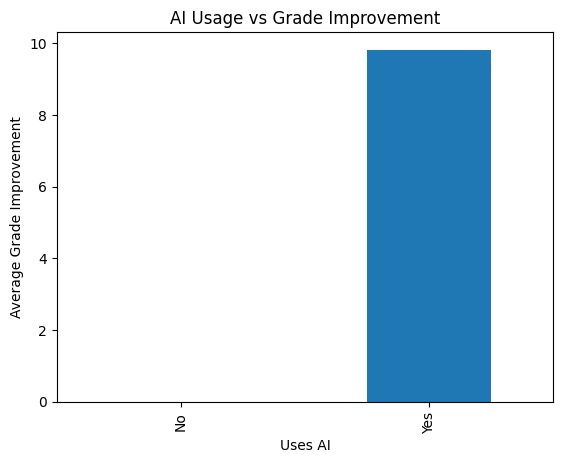

In [ ]:
import matplotlib.pyplot as plt  # 1번) 막대그래프 시각

df.groupby('uses_ai')['grade_improvement'].mean().plot(kind='bar')

plt.title('AI Usage vs Grade Improvement')
plt.xlabel('Uses AI')
plt.ylabel('Average Grade Improvement')

plt.show()

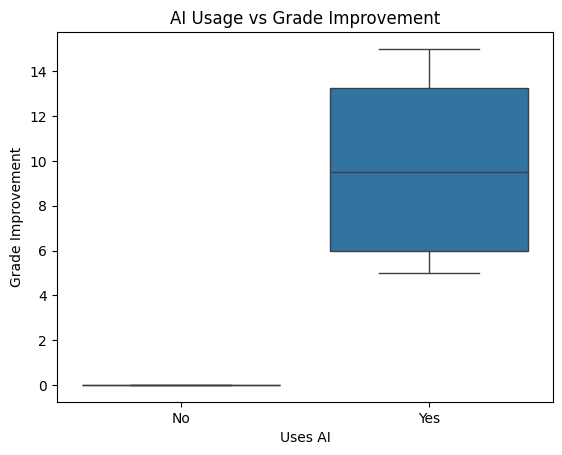

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt # 2번 박스 플롯.

sns.boxplot(x='uses_ai', y='grade_improvement', data=df)

plt.title('AI Usage vs Grade Improvement')
plt.xlabel('Uses AI')
plt.ylabel('Grade Improvement')

plt.show()

# 박스플롯 분석 결과, AI 사용 그룹의 중앙값이 AI 미사용 그룹보다 훨씬 높게 나타났습니다. 또한 AI 사용 학생들은 전반적으로 성적 향상 분포가 더 높은 경향을 보였습니다.

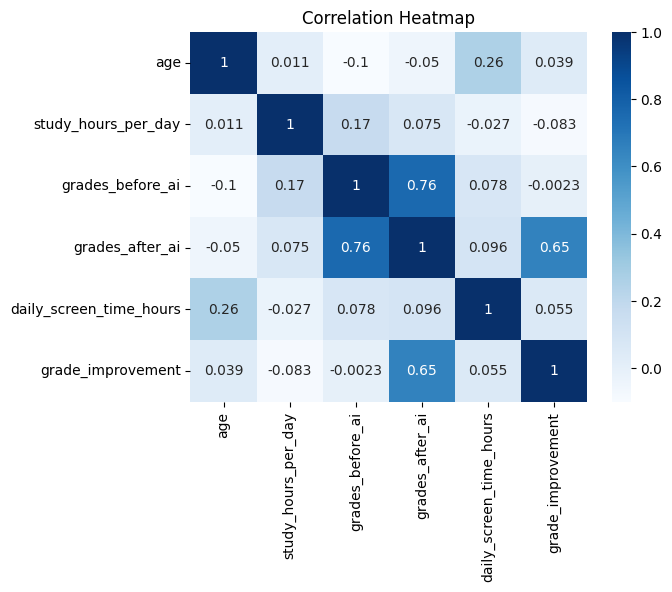

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64']) # 3번 히트맵, 변수들 간의 상관관계파악 용이.


sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title('Correlation Heatmap')

plt.show()

# 1) AI 사용 전 성적과 사용 후 성적 사이에서 높은 양의 상관관계(0.76)가 나타났습니다. 이는 기존 성적이 높은 학생들이 이후에도 높은 성적을 유지하는 경향이 있음을 의미합니다.
# 2) 그리고 AI 사용 후 성적과 성적향상 변수 사이에서도 중간 이상의 양의 상관관계(0.65)가 나타났습니다. 평균보다 조금 높다.
# 3) 하루 평균 공부 시간과 성적향상 변수 사이에서는 뚜렷한 상관관계가 나타나지 않았습니다(-0.083)
# 4) 화면 사용 시간과 성적향상 변수 사이에서는 뚜렷한 관계가 나타나지 않았습니다.(0.055)

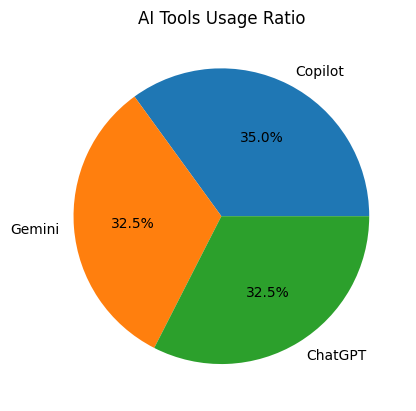

In [ ]:
df['ai_tools_used'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('AI Tools Usage Ratio')

plt.ylabel('')

plt.show()

# 4번 파이차트이용!
# 학생들이 사용하는 AI 도구 비율을 확인한 결과, Copilot, ChatGPT, Gemini의 사용 비율이 비교적 비슷하게 나타났습니다.

# 3) 마무리

## 이번 분석에서는 총 100명의 학생 데이터를 기반으로 AI 활용과 성적 향상 사이의 관계를 분석하였으며, 이를 통해 AI 활용이 학업 성취도 향상과 일정 부분 관련이 있을 가능성을 확인할 수 있었습니다. 다만 본 데이터는 제한된 표본을 기반으로 한 분석이기 때문에, 보다 다양한 환경과 추가적인 데이터 분석이 필요할 것으로 생각됩니다.

## 감사합니다. ( 이 부분을 ppt로 만들면 수요일 발표작업끝)